# Imports and Defs

In [1]:
import time as _time

import numpy as _np
import matplotlib.pyplot as plt

from siriuspy.oscilloscope import Keysight, Scopes, ScopeSignals

def plot_waveforms(wfms):
    for chan in wfms:
        plt.plot(1e6*wfms[chan][0], 1e3*wfms[chan][1], label=chan)
    plt.xlabel('time [µs]')
    plt.ylabel('Voltage [mV]')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

# Test Scopes and ScopeSignals

In [2]:
print(ScopeSignals.LI_ICT1)

print(ScopeSignals.get_scopesignal('LI_ICT1'))
print(ScopeSignals.get_scopesignal(ScopeSignals.LI_ICT1))

print(ScopeSignals.get_channel(ScopeSignals.LI_ICT1))
print(ScopeSignals.get_channel(ScopeSignals.LI_ICT2))
print(ScopeSignals.get_channel(ScopeSignals.TB_ICT1))
print(ScopeSignals.get_channel(ScopeSignals.TB_ICT2))

('LI_ICT1', 'LI_DI_ICTOSC', 'channel1')
('LI_ICT1', 'LI_DI_ICTOSC', 'channel1')
('LI_ICT1', 'LI_DI_ICTOSC', 'channel1')
channel1
channel2
channel3
channel4


In [3]:
print(Scopes.LI_DI_ICTOSC)

scopename      : LI_DI_ICTOSC
model          : Keysight DSOS104A Infiniium, Softare version 06.74.01101, Firmware version V29120001
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'STT', 'MIN', 'MAX', 'AVG', 'STD', 'COUNT')


In [4]:
scope = Scopes.get_scope(ScopeSignals.LI_ICT1)
print(scope)

scopename      : LI_DI_ICTOSC
model          : Keysight DSOS104A Infiniium, Softare version 06.74.01101, Firmware version V29120001
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'STT', 'MIN', 'MAX', 'AVG', 'STD', 'COUNT')


In [5]:
print(Scopes.get_scope(ScopeSignals.MODLTR1_PULSE))

scopename      : LI_PU_OSC_MODLTR
model          : None
ipaddr         : 10.128.150.20
hostname       : KEYSIGH-QQI8MNR.abtlus.org.br
port           : 5025
channel1       : MODLTR1_PULSE
channel2       : None
channel3       : MODLTR2_PULSE
channel4       : None
stats_fields   : None


# Test Keysight

In [2]:
scope = Scopes.TS_PU_EJEBO; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.LI_PU_MODLTR; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.TS_PU_INJSI; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.AS_DI_FCT; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.AS_DI_FPM; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.TB_PU_INJBO; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.LI_DI_ICT; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.SI_PU_INJSI; print(f'{scope.scopename:<20s} : {scope.get_identification()}')

TS_PU_EJEBO          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500104,06.75.00010
LI_PU_MODLTR         : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500105,06.50.01004
TS_PU_INJSI          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500106,06.75.00010
AS_DI_FCT            : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500107,06.74.00204
AS_DI_FPM            : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500108,06.10.00804
TB_PU_INJBO          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500109,06.75.00010
LI_DI_ICT            : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500110,06.74.01101
SI_PU_INJSI          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500111,06.75.00010


In [4]:
k = Scopes.LI_DI_ICT
print(k)

scopename      : LI_DI_ICT
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


In [4]:
t0 = _time.time()
idn = k.get_identification()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 153.230 ms


In [5]:
idn

'KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500110,06.74.01101'

In [3]:
t0 = _time.time()
k.channel_select('channel1')
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 0.621 ms


In [4]:
t0 = _time.time()
k.scales_read('channel1')
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 585.753 ms


In [5]:
print(k.channels_scales)

{'channel1': (2.5e-11, 5.26875e-06, 0.0917109)}


In [6]:
t0 = _time.time()
k.scales_update_all()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 1155.457 ms


In [7]:
print(k.channels_scales)

{'channel1': (2.5e-11, 5.26875e-06, 0.0917109), 'channel2': (2.5e-11, 5.2692e-06, 0.0821114), 'channel3': (2.5e-11, 5.26945e-06, 0.00531161), 'channel4': (2.5e-11, 5.27047e-06, 0.00531263)}


In [8]:
t0 = _time.time()
k.wfm_config()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 0.664 ms


In [9]:
t0 = _time.time()
k.wfm_read_raw()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 330.331 ms


In [10]:
t0 = _time.time()
datax, datay = k.wfm_read_channel('channel1')
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 160.159 ms


In [11]:
t0 = _time.time()
data = k.wfm_read()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 546.545 ms


In [5]:
k.meas_read()

{'Charge-TB-ICT2': {'CURR': 1.91676e-09,
  'MEAN': 0.0,
  'MIN': 1.91676e-09,
  'MAX': 1.91676e-09,
  'RANGE': 1.91676e-09,
  'STD': 0.0,
  'COUNT': 1.0},
 'Charge-TB-ICT1': {'CURR': 1.06913e-09,
  'MEAN': 0.0,
  'MIN': 1.06913e-09,
  'MAX': 1.06913e-09,
  'RANGE': 1.06913e-09,
  'STD': 0.0,
  'COUNT': 1.0},
 'Charge-LI-ICT2': {'CURR': 1.27981e-09,
  'MEAN': 0.0,
  'MIN': 1.27981e-09,
  'MAX': 1.27981e-09,
  'RANGE': 1.27981e-09,
  'STD': 0.0,
  'COUNT': 1.0},
 'Charge-LI-ICT1': {'CURR': 1.298e-09,
  'MEAN': 0.0,
  'MIN': 1.298e-09,
  'MAX': 1.298e-09,
  'RANGE': 1.298e-09,
  'STD': 0.0,
  'COUNT': 1.0}}

In [12]:
print(data)

{'LI_ICT1': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([ 0.00087765,  0.00087765,  0.0008355 , ..., -0.00148275,
       -0.0014406 , -0.0015249 ])), 'LI_ICT2': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([0.00227248, 0.00231464, 0.00223033, ..., 0.00096572, 0.00079711,
       0.00079711])), 'TB_ICT1': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([ 8.431560e-05,  4.216000e-05, -4.215120e-05, ..., -3.793960e-04,
       -3.793960e-04, -4.637072e-04])), 'TB_ICT2': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([0.00805327, 0.00809544, 0.00809544, ..., 0.00796895, 0.00792678,
       0.00788462]))}


In [13]:
t0 = _time.time()
k.scales_update_all()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 1021.168 ms


In [14]:
for _ in range(10):
    t0 = _time.time()
    meas, wfms = k.acquire(acq_meas=True, acq_wfms=True)
    t1 = _time.time()
    print(f'time: {1e3*(t1-t0):.3f} ms')

time: 1057.275 ms
time: 1279.854 ms
time: 1118.965 ms
time: 1270.237 ms
time: 1152.530 ms
time: 1256.594 ms
time: 1145.095 ms
time: 1317.156 ms
time: 1131.832 ms
time: 1179.202 ms


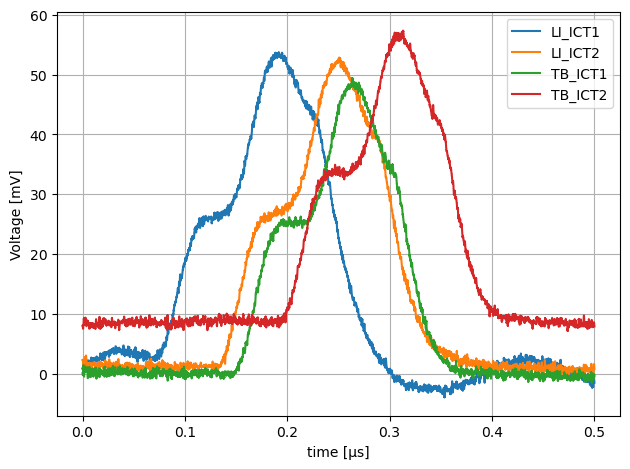

In [15]:
plot_waveforms(wfms)

In [14]:
t0 = _time.time()
dr = k.setup_fetch()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 285.295 ms


In [15]:
t0 = _time.time()
drc = k.setup_compress(dr)
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 336.164 ms


In [16]:
t0 = _time.time()
drdc = k.setup_decompress(drc)
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 5.989 ms


In [17]:
len(dr), len(drc), len(drdc)

(2438333, 68252, 2438333)

In [13]:
k.setup_apply(drdc)

IDN: KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500110,06.74.01101
Downloaded setup: 2438333 bytes
wfms and meas acquisition took 1.2582 s
{'Charge-TB-ICT2': {'CURR': 1.91676e-09, 'MEAN': 0.0, 'MIN': 1.91676e-09, 'MAX': 1.91676e-09, 'RANGE': 1.91676e-09, 'STD': 0.0, 'COUNT': 1.0}, 'Charge-TB-ICT1': {'CURR': 1.06913e-09, 'MEAN': 0.0, 'MIN': 1.06913e-09, 'MAX': 1.06913e-09, 'RANGE': 1.06913e-09, 'STD': 0.0, 'COUNT': 1.0}, 'Charge-LI-ICT2': {'CURR': 1.27981e-09, 'MEAN': 0.0, 'MIN': 1.27981e-09, 'MAX': 1.27981e-09, 'RANGE': 1.27981e-09, 'STD': 0.0, 'COUNT': 1.0}, 'Charge-LI-ICT1': {'CURR': 1.298e-09, 'MEAN': 0.0, 'MIN': 1.298e-09, 'MAX': 1.298e-09, 'RANGE': 1.298e-09, 'STD': 0.0, 'COUNT': 1.0}}


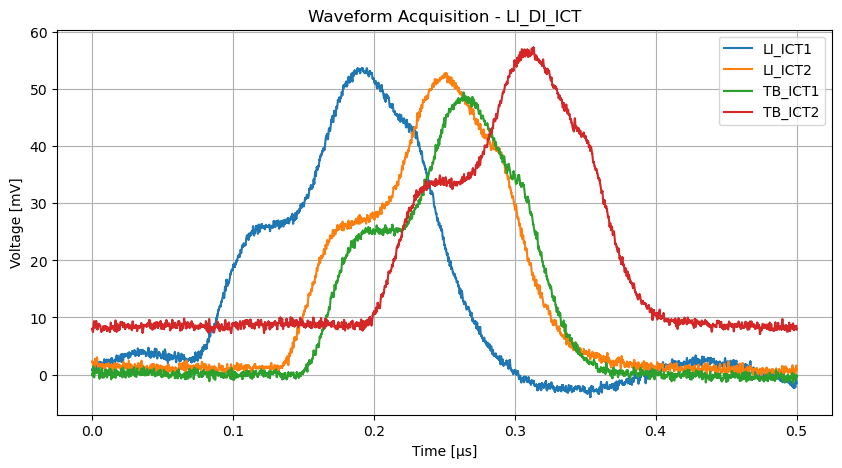

In [6]:
import time
import matplotlib.pyplot as plt

from siriuspy.oscilloscope import Scopes

scope = Scopes.LI_DI_ICT

print("IDN:", scope.get_identification())

setup = scope.setup_fetch()
print(f"Downloaded setup: {len(setup)} bytes")

t0 = time.time()
meas, wfms = scope.acquire(acq_meas=True, acq_wfms=True)
t1 = time.time()
print(f'wfms and meas acquisition took {(t1-t0):.4f} s')

# Plot acquired waveforms
plt.figure(figsize=(10, 5))
for signal_name, (datax, datay) in wfms.items():
    plt.plot(datax * 1e6, 1e3*datay, label=signal_name)

plt.xlabel("Time [μs]")
plt.ylabel("Voltage [mV]")
plt.title(f"Waveform Acquisition - {scope.scopename}")
plt.grid(True)
plt.legend()
plt.show()

scope.disconnect()

In [8]:
k

NameError: name 'k' is not defined